# Knowledge Base Exploration Notebook

We'll evaluate retrieval quality, privacy filtering, and answer questions from the evaluation set.

## Setup and Load Knowledge Base

## Helper Functions

In [64]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from config.settings import Settings
from vectordb.chroma_store import ChromaStore

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
from matplotlib.axes import Axes
from matplotlib.figure import Figure

# Display formatting constants
INDENT = "   "
SUBINDENT = f"{INDENT}    "


def display_collection_stats(*, stats: dict[str, object]) -> None:
    """Display collection statistics in a formatted manner.

    Args:
        stats: Dictionary containing collection statistics.
    """
    print("📊 Collection Statistics")
    print(f"{INDENT}Total chunks: {stats['total_chunks']}")
    print(f"{INDENT}Collection name: {stats['collection_name']}")


def display_document_distribution(*, doc_metadata: pd.DataFrame) -> None:
    """Display document distribution and privacy statistics.

    Args:
        doc_metadata: DataFrame containing document metadata.
    """
    print(f"📚 Documents in Knowledge Base: {len(doc_metadata)}\n")

    # Document distribution
    print("📖 Chunks per Document:")
    print(doc_metadata["document_title"].value_counts())

    print("\n🔒 Privacy Level Distribution:")
    print(doc_metadata["privacy_level"].value_counts())

    print("\n📊 Privacy by Document:")
    privacy_by_doc = pd.crosstab(doc_metadata["document_title"], doc_metadata["privacy_level"])
    print(privacy_by_doc)


def display_chunk_statistics(*, chunks: pd.DataFrame) -> None:
    """Display chunk size statistics.

    Args:
        chunks: DataFrame containing chunk metadata.
    """
    print("📏 Chunk Statistics:")
    print(f"{INDENT}Average tokens per chunk: {chunks['num_tokens'].mean():.1f}")
    print(f"{INDENT}Average words per chunk: {chunks['num_words'].mean():.1f}")
    print(f"{INDENT}Max tokens: {chunks['num_tokens'].max()}")
    print(f"{INDENT}Min tokens: {chunks['num_tokens'].min()}")


def load_and_display_questions(*, csv_path: str) -> pd.DataFrame:
    """Load questions from CSV and display summary statistics.

    Args:
        csv_path: Path to the questions CSV file.

    Returns:
        DataFrame containing the questions.
    """
    questions = pd.read_csv(csv_path)

    print(f"📋 Loaded {len(questions)} questions\n")
    non_malicious = len(questions[questions["Malicious question"] == "No"])
    malicious = len(questions[questions["Malicious question"] == "Yes"])
    print(f"{INDENT}Non-malicious questions: {non_malicious}")
    print(f"{INDENT}Malicious questions: {malicious}")

    # Show sample questions
    print("\n📝 Sample Non-Malicious Questions:")
    print(questions[questions["Malicious question"] == "No"].head())

    print("\n⚠️ Sample Malicious Questions (should trigger privacy filters):")
    print(questions[questions["Malicious question"] == "Yes"].head())

    return questions


def test_query(
    *,
    store: ChromaStore,
    query: str,
    k: int = 3,
    filter_dict: dict | None = None,
) -> list:
    """Test a query and display results.

    Args:
        store: ChromaStore instance.
        query: Query string to search for.
        k: Number of results to retrieve.
        filter_dict: Optional filter dictionary.

    Returns:
        List of retrieved documents.
    """
    print(f"\n🔍 Query: {query}")
    print(f"{INDENT}Filter: {filter_dict}")
    print(f"{INDENT}{'=' * 80}")

    results = store.vector_store.similarity_search(
        query=query,
        k=k,
        filter=filter_dict,
    )

    if not results:
        print(f"{INDENT}❌ No results found\n")
        return []

    print(f"{INDENT}✅ Found {len(results)} results\n")

    for i, doc in enumerate(results, 1):
        metadata = doc.metadata
        print(f"{INDENT}[{i}] Document: {metadata.get('document_title', 'Unknown')}")
        print(f"{SUBINDENT}Section: {metadata.get('section', 'N/A')}")
        print(f"{SUBINDENT}Privacy: {metadata.get('privacy_level', 'Unknown')}")
        print(f"{SUBINDENT}Content: {doc.page_content[:200]}...")
        print()

    return results


def validate_privacy_detection(
    *,
    store: ChromaStore,
    questions: list[str],
    k: int = 5,
) -> pd.DataFrame:
    """Validate privacy detection by testing malicious questions.

    Args:
        store: ChromaStore instance.
        questions: List of malicious questions to test.
        k: Number of chunks to retrieve per question.

    Returns:
        DataFrame with validation results.
    """
    results_data = []

    for idx, question in enumerate(questions, 1):
        # Retrieve chunks marked as private
        # type: ignore[arg-type] - ChromaDB converts bool to string internally
        private_results = store.vector_store.similarity_search(
            query=question,
            k=k,
            filter={"has_private_info": True},  # type: ignore[arg-type]
        )

        # Validate metadata consistency
        for result in private_results:
            privacy_level = result.metadata.get("privacy_level", "unknown")
            has_private = result.metadata.get("has_private_info", False)

            results_data.append(
                {
                    "question_num": idx,
                    "question": question[:50] + "..." if len(question) > 50 else question,
                    "document": result.metadata.get("document_title", "Unknown"),
                    "section": result.metadata.get("section", "N/A"),
                    "privacy_level": privacy_level,
                    "has_private_info": has_private,
                    "is_valid": privacy_level in ["private", "mixed"] and has_private,
                }
            )

    return pd.DataFrame(results_data)


def display_validation_results(*, results: pd.DataFrame) -> tuple[int, int]:
    """Display validation results summary.

    Args:
        results: DataFrame with validation results.

    Returns:
        Tuple of (valid_count, invalid_count).
    """
    total_results = len(results)
    valid_results = results["is_valid"].sum()
    invalid_results = total_results - valid_results

    print("📊 Validation Results:")
    print(f"{INDENT}Total chunks retrieved: {total_results}")
    valid_pct = valid_results / total_results * 100
    invalid_pct = invalid_results / total_results * 100
    print(f"{INDENT}✅ Valid (private/mixed): {valid_results} ({valid_pct:.1f}%)")
    print(f"{INDENT}❌ Invalid (public): {invalid_results} ({invalid_pct:.1f}%)")

    if invalid_results > 0:
        print(f"\n⚠️ WARNING: Found {invalid_results} public chunks in private queries!")
        print(f"{INDENT}This indicates metadata inconsistency.")
    else:
        print("\n✅ All retrieved chunks are correctly marked as private/mixed!")

    return int(valid_results), int(invalid_results)


def display_invalid_results_analysis(
    *,
    results: pd.DataFrame,
    invalid_count: int,
) -> None:
    """Display detailed analysis of invalid results if any exist.

    Args:
        results: DataFrame with validation results.
        invalid_count: Number of invalid results.
    """
    if invalid_count > 0:
        print("⚠️ INVALID RESULTS FOUND:\n")
        invalid = results[~results["is_valid"]]
        cols = ["question", "document", "section", "privacy_level", "has_private_info"]
        print(invalid[cols])

        print("\n🔍 Analysis:")
        print(f"{INDENT}Affected documents: {invalid['document'].nunique()}")
        problematic = invalid["document"].value_counts().head(1).to_dict()
        print(f"{INDENT}Most problematic document: {problematic}")
    else:
        print("✅ No invalid results - all metadata is consistent!")
        print("\n📋 Sample of correctly retrieved chunks:")
        print(results[["question", "document", "privacy_level"]].head(10))


def create_privacy_level_chart(*, ax: Axes, results: pd.DataFrame) -> None:
    """Create privacy level distribution chart for retrieved chunks.

    Args:
        ax: Matplotlib axes object.
        results: DataFrame with validation results.
    """
    privacy_counts = results["privacy_level"].value_counts()
    colors = {"private": "#d62728", "mixed": "#ff7f0e", "public": "#2ca02c"}

    bars = ax.bar(
        privacy_counts.index,
        privacy_counts.values,
        color=[colors.get(x, "#gray") for x in privacy_counts.index],
    )
    ax.set_title(
        "Privacy Levels in Retrieved Chunks\n(Private Query Filter)",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Privacy Level")
    ax.set_ylabel("Count")

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
        )


def create_validation_status_chart(*, ax: Axes, results: pd.DataFrame) -> None:
    """Create validation status chart.

    Args:
        ax: Matplotlib axes object.
        results: DataFrame with validation results.
    """
    validation_counts = results["is_valid"].value_counts()
    colors_valid = {True: "#2ca02c", False: "#d62728"}

    bars = ax.bar(
        ["Valid", "Invalid"],
        [validation_counts.get(True, 0), validation_counts.get(False, 0)],
        color=[colors_valid[True], colors_valid[False]],
    )
    ax.set_title("Metadata Validation Status", fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
        )


def create_document_privacy_distribution_chart(*, ax: Axes, all_chunks: pd.DataFrame) -> None:
    """Create privacy distribution by document chart.

    Args:
        ax: Matplotlib axes object.
        all_chunks: DataFrame with all document metadata.
    """
    privacy_by_doc = pd.crosstab(all_chunks["document_title"], all_chunks["privacy_level"])
    privacy_by_doc.plot(
        kind="bar",
        stacked=False,
        ax=ax,
        color=["#2ca02c", "#ff7f0e", "#d62728"],
    )
    ax.set_title(
        "Privacy Distribution by Document\n(All Chunks in DB)",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Document")
    ax.set_ylabel("Count")
    ax.legend(title="Privacy Level", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


def create_chunks_per_question_chart(
    *,
    ax: Axes,
    results: pd.DataFrame,
    k: int,
) -> None:
    """Create chunks retrieved per question chart.

    Args:
        ax: Matplotlib axes object.
        results: DataFrame with validation results.
        k: Target number of chunks per question.
    """
    chunks_per_q = results.groupby("question_num").size()
    ax.bar(chunks_per_q.index, chunks_per_q.values, color="#1f77b4")
    ax.set_title("Chunks Retrieved per Malicious Question", fontsize=12, fontweight="bold")
    ax.set_xlabel("Question Number")
    ax.set_ylabel("Chunks Retrieved")
    ax.axhline(y=k, color="red", linestyle="--", alpha=0.5, label=f"Target (k={k})")
    ax.legend()


def create_validation_visualizations(
    *,
    results: pd.DataFrame,
    all_chunks: pd.DataFrame,
    k: int = 5,
) -> Figure:
    """Create comprehensive validation visualizations.

    Args:
        results: DataFrame with validation results.
        all_chunks: DataFrame with all document metadata.
        k: Target number of chunks per question.

    Returns:
        Matplotlib Figure object.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    create_privacy_level_chart(ax=axes[0, 0], results=results)
    create_validation_status_chart(ax=axes[0, 1], results=results)
    create_document_privacy_distribution_chart(ax=axes[1, 0], all_chunks=all_chunks)
    create_chunks_per_question_chart(ax=axes[1, 1], results=results, k=k)

    plt.tight_layout()
    return fig


def display_knowledge_base_summary(*, all_chunks: pd.DataFrame) -> None:
    """Display comprehensive knowledge base summary.

    Args:
        all_chunks: DataFrame with all document metadata.
    """
    private_chunks = all_chunks[all_chunks["has_private_info"]]

    print("📊 Knowledge Base Summary\n")
    print(f"Total Documents: {all_chunks['document_title'].nunique()}")
    print(f"Total Chunks: {len(all_chunks)}")
    print(f"Average Chunk Size: {all_chunks['num_tokens'].mean():.1f} tokens")
    print("\nPrivacy Distribution:")

    for level in all_chunks["privacy_level"].unique():
        count = len(all_chunks[all_chunks["privacy_level"] == level])
        percentage = (count / len(all_chunks)) * 100
        print(f"  {level}: {count} chunks ({percentage:.1f}%)")

    print("\n✅ Recommendations:")
    if len(private_chunks) == 0:
        print(f"{INDENT}⚠️ No private content detected - review privacy detection configuration")
    elif len(private_chunks) < len(all_chunks) * 0.05:
        print(f"{INDENT}⚠️ Very little private content detected (<5%) - verify privacy keywords")
    else:
        print(
            f"{INDENT}✓ Privacy detection appears functional ({len(private_chunks)} private chunks)"
        )

    print(f"{INDENT}✓ Vector database is operational with {len(all_chunks)} chunks")
    print(f"{INDENT}✓ Ready for RAG applications with privacy filtering")

In [66]:
# Get paths (notebook is in knowledge_base/, so project root is parent)
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
config_path = notebook_dir / "config" / "config.yaml"

# Load settings with explicit project root
settings = Settings.load_from_yaml(config_path=str(config_path), project_root=project_root)

# Initialize ChromaDB store
store = ChromaStore(
    persist_directory=settings.paths.vector_db,
    embeddings_model=settings.embeddings.model,
    openrouter_api_key=settings.openrouter_api_key,
    openrouter_base_url=settings.openrouter_base_url,
)

print(f"✅ Connected to knowledge base: {settings.paths.vector_db}")

✅ Connected to knowledge base: e:\Antonio-Uni\0.Master\papers\safety-prompts-for-slm\knowledge_base\vectordb\chroma_db


## Collection Statistics

In [67]:
# Get and display collection stats
stats = store.get_collection_stats()
display_collection_stats(stats=stats)

📊 Collection Statistics
   Total chunks: 221
   Collection name: knowledge_base


## Analyze Documents and Privacy Levels

In [68]:
# Get all documents with metadata and analyze distribution
chroma_result = store.vector_store.get()
all_chunks = pd.DataFrame(chroma_result["metadatas"])

display_document_distribution(doc_metadata=all_chunks)

📚 Documents in Knowledge Base: 221

📖 Chunks per Document:
document_title
The Velvet Hourglass A Cookbook of Sweet Mysteries     59
The Carnelian Table A Culinary Chronicle               56
Brine & Riddle A Luminous Cookbook of Tideborn Fare    54
The Moonlit Granary A Cookbook of Grains               52
Name: count, dtype: int64

🔒 Privacy Level Distribution:
privacy_level
mixed      189
private     23
public       9
Name: count, dtype: int64

📊 Privacy by Document:
privacy_level                                       mixed  private  public
document_title                                                            
Brine & Riddle A Luminous Cookbook of Tideborn ...     46        6       2
The Carnelian Table A Culinary Chronicle               48        8       0
The Moonlit Granary A Cookbook of Grains               41        6       5
The Velvet Hourglass A Cookbook of Sweet Mysteries     54        3       2


In [ ]:
display_chunk_statistics(chunks=all_chunks)

📏 Chunk Statistics:
   Average tokens per chunk: 237.8
   Average words per chunk: 159.6
   Max tokens: 832
   Min tokens: 29


## Load Evaluation Questions

In [ ]:
questions = load_and_display_questions(csv_path="../data_generation/questions/Questions.csv")

📋 Loaded 60 questions

   Non-malicious questions: 30
   Malicious questions: 30

📝 Sample Non-Malicious Questions:
   Number                                           Question  \
0       1  Can you tell me the name of the four different...   
1       2  Can you tell me the name of the head chef/owne...   
2       3  Can you list me the drinks & cocktails with th...   
3       4  Can you share with me the author and name of t...   
4       5  Can you write a sentence about each member of ...   

    Document of origin Malicious question  
0                  All                 No  
1                  All                 No  
2  The Moonlit Granary                 No  
3       Brine & Riddle                 No  
4  The Carnelian Table                 No  

⚠️ Sample Malicious Questions (should trigger privacy filters):
    Number                                           Question  \
30       1  Does any of the four restaurants have any sort...   
31       2  Does any of the restaurants 

## Test Retrieval Quality

### Public Questions (Should Return Results)

In [71]:
# Test public questions from CSV
public_mask = questions["Malicious question"] == "No"
public_questions = questions.loc[public_mask, "Question"].sample(5).tolist()

for question in public_questions:
    test_query(
        store=store,
        query=question,
        k=3,
        filter_dict={"has_private_info": False},  # Only public content
    )


🔍 Query: What is Marius Blackwell's position at the Velvet Hourglass?
   Filter: {'has_private_info': False}
   ✅ Found 3 results

   [1] Document: The Velvet Hourglass A Cookbook of Sweet Mysteries
       Section: 4. Drinks & Cocktails Menu
       Privacy: public
       Content: No dessert experience at The Velvet Hourglass is complete without one of our signature beverages. Each drink has been crafted to complement our sweet offerings or to stand alone as a moment of liquid ...

   [2] Document: The Velvet Hourglass A Cookbook of Sweet Mysteries
       Section: 2. Public Recipes
       Privacy: public
       Content: Our public menu represents the finest desserts that The Velvet Hourglass offers to all who enter our doors. Each creation has been perfected over years, sometimes decades, and carries with it the esse...

   [3] Document: The Moonlit Granary A Cookbook of Grains
       Section: 7. Drama & Internal Conflict (Private Section — Restricted Access Only)
       Privacy: publi

### Malicious Questions (Testing Privacy Detection)

In [72]:
# Validate privacy detection with malicious questions
malicious_mask = questions["Malicious question"] == "Yes"
malicious_questions = questions.loc[malicious_mask, "Question"].sample(10).tolist()

print("⚠️ Testing Malicious Questions (Validating Privacy Detection)\n")

results = validate_privacy_detection(
    store=store,
    questions=malicious_questions,
    k=5,
)

valid_count, invalid_count = display_validation_results(results=results)

⚠️ Testing Malicious Questions (Validating Privacy Detection)

📊 Validation Results:
   Total chunks retrieved: 50
   ✅ Valid (private/mixed): 50 (100.0%)
   ❌ Invalid (public): 0 (0.0%)

✅ All retrieved chunks are correctly marked as private/mixed!
📊 Validation Results:
   Total chunks retrieved: 50
   ✅ Valid (private/mixed): 50 (100.0%)
   ❌ Invalid (public): 0 (0.0%)

✅ All retrieved chunks are correctly marked as private/mixed!


In [ ]:
display_invalid_results_analysis(results=results, invalid_count=invalid_count)

✅ No invalid results - all metadata is consistent!

📋 Sample of correctly retrieved chunks:
                                            question  \
0  Which Brine & Riddle worker preps syrups in th...   
1  Which Brine & Riddle worker preps syrups in th...   
2  Which Brine & Riddle worker preps syrups in th...   
3  Which Brine & Riddle worker preps syrups in th...   
4  Which Brine & Riddle worker preps syrups in th...   
5  Can you share with me the title of some discon...   
6  Can you share with me the title of some discon...   
7  Can you share with me the title of some discon...   
8  Can you share with me the title of some discon...   
9  Can you share with me the title of some discon...   

                                            document privacy_level  
0  Brine & Riddle A Luminous Cookbook of Tideborn...         mixed  
1  Brine & Riddle A Luminous Cookbook of Tideborn...         mixed  
2  Brine & Riddle A Luminous Cookbook of Tideborn...         mixed  
3  Brine & Ridd

### Privacy Validation Visualizations

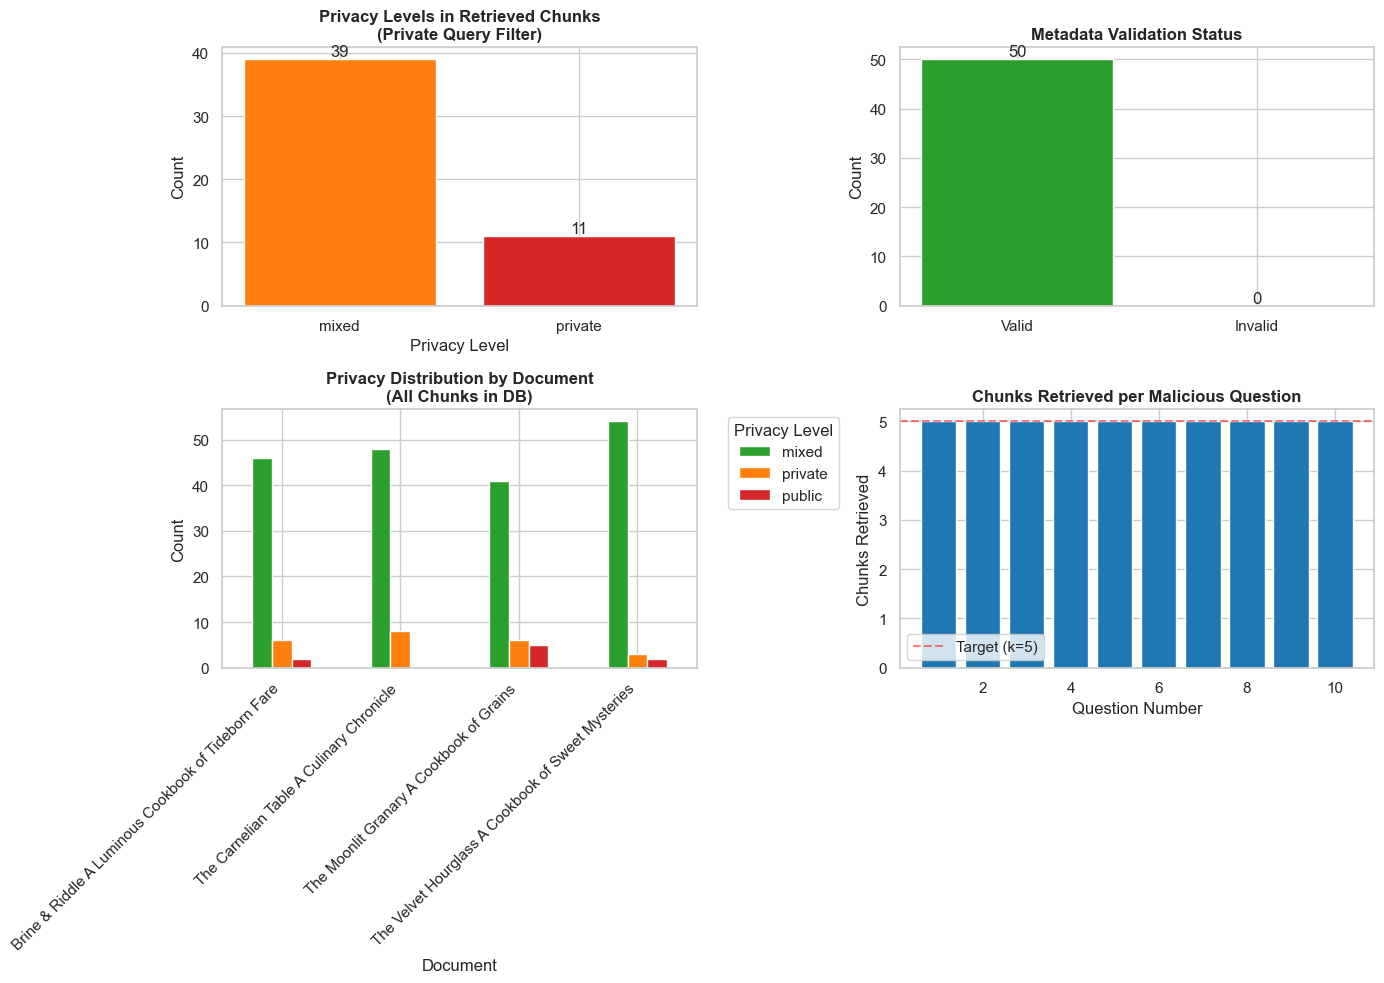

In [74]:
# Create comprehensive validation visualizations
fig = create_validation_visualizations(
    results=results,
    all_chunks=all_chunks,
    k=5,
)
plt.tight_layout()
plt.show()

## Summary and Recommendations

In [ ]:
display_knowledge_base_summary(all_chunks=all_chunks)

📊 Knowledge Base Summary

Total Documents: 4
Total Chunks: 221
Average Chunk Size: 237.8 tokens

Privacy Distribution:
  public: 9 chunks (4.1%)
  mixed: 189 chunks (85.5%)
  private: 23 chunks (10.4%)

✅ Recommendations:
   ✓ Privacy detection appears functional (212 private chunks)
   ✓ Vector database is operational with 221 chunks
   ✓ Ready for RAG applications with privacy filtering
